In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN

import sys
sys.path.append("..")

from src import IOFunctions


from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import HelperFunctions
H_F = HelperFunctions.Helper_Functions()

import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

#data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = '../Camera_Calibrations/Ximea_Camera'
#data_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee\Data\Salix\Ximea_Calibration'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

In [2]:
def collect_traces(data, dbscan_labels, image_stack, image_size=12):
    labels = np.sort(np.unique(dbscan_labels))
    labels = labels[labels > -1]
    trace_matrix = np.zeros([len(labels), image_stack.shape[0]])
    locations = np.zeros([2, len(labels)])

    for i, label in enumerate(labels):
        locations[0, i] = np.nanmean(data['xc'][dbscan_labels == label].to_numpy())
        locations[1, i] = np.nanmean(data['yc'][dbscan_labels == label].to_numpy())
        xmin = int(locations[0, i])-int(image_size/2)
        xmax = int(locations[0, i])+int(image_size/2)
        ymin = int(locations[1, i])-int(image_size/2)
        ymax = int(locations[1, i])+int(image_size/2)
        trace_matrix[i, :] = np.sum(np.sum(image_stack[:, xmin:xmax, ymin:ymax], axis=-1), axis=-1)
        print(
                "Summed trace {}/{}".format(
                    i + 1, len(labels)
                ),
                end="\r",
                flush=True,
            )

    return locations, trace_matrix

In [3]:
def average_parameters(data, dbscan_labels):
    labels = np.sort(np.unique(dbscan_labels))
    labels = labels[labels > -1]
    dict_obj = {}
    dict_obj['photons'] = np.zeros(len(labels))
    dict_obj['frames'] = np.zeros(len(labels))
    for column in np.array(data.columns):
        if column == 'index':
            continue
        else:
            dict_obj[column] = np.zeros(len(labels))
    
    for label in labels:
        for column in np.array(data.columns):
            if column == 'index':
                continue
            elif column in ['A_B', 'A_G', 'A_R']:
                dict_obj[column][label] = np.sum(data[column][dbscan_labels == label])
            else:
                dict_obj[column][label] = np.mean(data[column][dbscan_labels == label])
        dict_obj['frames'][label] = len(data[column][dbscan_labels == label])
        dict_obj['photons'][label] = np.sum(data['A_B'][dbscan_labels == label]) + np.sum(data['A_G'][dbscan_labels == label]) + np.sum(data['A_R'][dbscan_labels == label])
    dict_obj['A_B'] = dict_obj['A_B']/dict_obj['photons']
    dict_obj['A_G'] = dict_obj['A_G']/dict_obj['photons']
    dict_obj['A_R'] = dict_obj['A_R']/dict_obj['photons']
    df = pd.DataFrame.from_dict(dict_obj)
    return df

In [4]:
def extract_single_molecules(localisation_files, chi_val=None):
    columns = ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G', 'bg_R', 'A_B', 'A_G', 'A_R',
       'chi_sqr', 'frame', 'xc_err', 'yc_err', 's_x_err', 's_y_err',
       'bg_B_err', 'bg_G_err', 'bg_R_err', 'A_B_err', 'A_G_err', 'A_R_err']

    for i, file in enumerate(localisation_files):
        loc_data = pd.read_hdf(file, columns=columns)
        if chi_val is None:
            chi_val = np.median(loc_data['chi_sqr'])
        loc_data = loc_data[loc_data['chi_sqr'] < chi_val]
        loc_data = loc_data[loc_data['xc_err'] < 1]
        loc_data = loc_data[loc_data['yc_err'] < 1]
        loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] < 10000]
        loc_data = loc_data.reset_index()
        X = np.vstack([loc_data['xc'], loc_data['yc']]).T
        loc_precision = 0.5*(np.mean(loc_data['xc_err']) + np.mean(loc_data['yc_err']))
        hdb = HDBSCAN(min_cluster_size=10, cluster_selection_epsilon=loc_precision)
        hdb.fit(X)
        df = average_parameters(loc_data, hdb.labels_)
        photons = loc_data['A_B']+loc_data['A_G']+loc_data['A_R']
        loc_data['photons'] = photons
        for column in np.array(loc_data.columns):
            if column in ['A_B', 'A_G', 'A_R']:
                loc_data[column] = loc_data[column]/photons
        if i == 0:
            single_frame_database = loc_data
            single_molecule_database = df
        else:
            single_frame_database = pd.concat([single_frame_database, loc_data])
            single_molecule_database = pd.concat([single_molecule_database, df])
    return single_molecule_database.reset_index(), single_frame_database.reset_index()

In [5]:
def extract_single_molecule_traces(localisation_file, chi_val=None):
    columns = ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G', 'bg_R', 'A_B', 'A_G', 'A_R',
       'chi_sqr', 'frame', 'xc_err', 'yc_err', 's_x_err', 's_y_err',
       'bg_B_err', 'bg_G_err', 'bg_R_err', 'A_B_err', 'A_G_err', 'A_R_err']

    image_file = localisation_file.split('.')[0]+'.ome.tif'
    metadata = localisation_file.split('.')[0]+'_metadata.txt'
    x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata)
    image_data, _, _ = IO.read_tiff_tophotoelectrons(image_file, smoothing_function, gain_map=gain[x_coord:x_coord+width, y_coord:y_coord+height], offset_map=offset[x_coord:x_coord+width, y_coord:y_coord+height], rqe=rqe[x_coord:x_coord+width, y_coord:y_coord+height], read_noise=readnoise[x_coord:x_coord+width, y_coord:y_coord+height], frame=np.arange(600))
    loc_data = pd.read_hdf(localisation_file, columns=columns)
    if chi_val is None:
        chi_val = np.median(loc_data['chi_sqr'])
    loc_data = loc_data[loc_data['chi_sqr'] < chi_val]
    loc_data = loc_data[loc_data['xc_err'] < 1]
    loc_data = loc_data[loc_data['yc_err'] < 1]
    loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] < 10000]
    loc_data = loc_data.reset_index()
    X = np.vstack([loc_data['xc'], loc_data['yc']]).T
    loc_precision = 0.5*(np.mean(loc_data['xc_err']) + np.mean(loc_data['yc_err']))
    hdb = DBSCAN(min_samples=10, eps=loc_precision)
    hdb.fit(X)
    locations, trace_matrix = collect_traces(loc_data, hdb.labels_, image_data)
    return locations, trace_matrix, image_data

In [6]:
dye_data_folders = np.array([r'/scratch2/jsb92/20250520_FRET/data/BSA_50pMDNAHJ/NotchFilter_785SP_10perc561_1'])

In [7]:
localisation_files = H_F.file_search(dye_data_folders[0], '.h5', '')

In [8]:
single_molecule_database, single_frame_database = extract_single_molecules(localisation_files, chi_val=3)

In [34]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-638-25x36'
shortpass_filter = 'semrock-bsp01-785r'
longpass_red_filter = 'semrock-blp01-635r'

longpass_blue_filter = 'semrock-blp01-488r'
bandpass_488_filter = 'semrock-ff01-520-44'
filters = [shortpass_filter, dichroic_mirror, notch_filter]
dye = 'Cy3'
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
dye_pixel_efficiency_Cy3 = dye_pixel_efficiency/np.sum(dye_pixel_efficiency)

Caught this error: Exception('Filter not in the fpbase.')


TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

In [24]:
dye_pixel_efficiency_Cy5

array([0.06335386, 0.19014143, 0.7465047 ])

In [13]:
dye = 'Cy5'
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
dye_pixel_efficiency_Cy5 = dye_pixel_efficiency/np.sum(dye_pixel_efficiency)

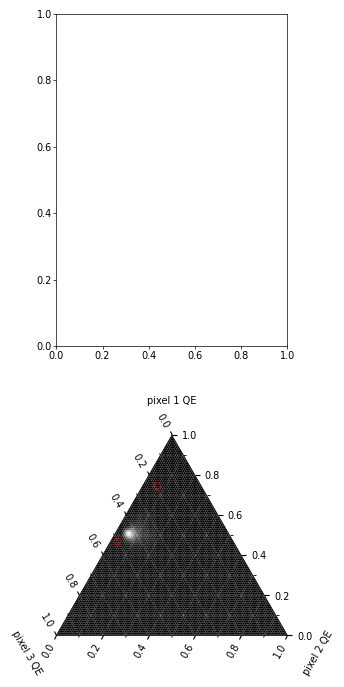

In [22]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1])

fig, axs = plotter.ternary_contour_plot(fig, axs, single_molecule_database['A_R'], single_molecule_database['A_G'], single_molecule_database['A_B'],
                                       R=[dye_pixel_efficiency_Cy3[2], dye_pixel_efficiency_Cy5[2]],
                                        G=[dye_pixel_efficiency_Cy3[1], dye_pixel_efficiency_Cy5[1]],
                                        B=[dye_pixel_efficiency_Cy3[0], dye_pixel_efficiency_Cy5[0]])

In [16]:
locations, trace_matrix, image_data = extract_single_molecule_traces(localisation_files[0], 2)

In [17]:
np.argsort(np.sum(trace_matrix, axis=1))

array([199,  72,  56, 157,  17, 133, 112, 141, 149, 102, 136, 187, 172,
       175, 119,  93,  21,  90,  33,  47,  68, 107, 177,  78, 152,  19,
        50, 170,  39,  88,  83, 196,  15,  49, 125, 104,   4, 165,  99,
        27, 158, 209, 117, 208, 161, 202, 143, 113,  14, 181, 189, 169,
       131,  37,  31, 191, 167,  60, 200, 166,  42,  71, 122, 164, 123,
       150, 108, 163, 206, 197, 146, 116, 162, 134, 114,  11,  62,  94,
        57, 105, 205, 147,  82,  75, 204,  22, 110, 153, 139,  73,  44,
       138,  28,  74, 132,   9,  96,  63, 144, 184,  38,  87, 126, 176,
        26, 127, 145,  59,  54,   2, 203, 151, 124,  43, 186, 101,  70,
       188, 111,  48,  34,  79, 118, 103, 121, 179,  36,  65,  53, 190,
        81,   7,  20,  91,  58, 115,  95,  25,  98, 182,  52, 193,  45,
        29, 173, 201, 195,  67, 135,  61, 198,  51, 128, 156,   5, 160,
       106,  89,  69, 130,   8,  76,  40, 109, 100, 140, 159,  16,  84,
       120,  46,  18,  30,  12, 154,   0, 194,  23,   1, 207, 17

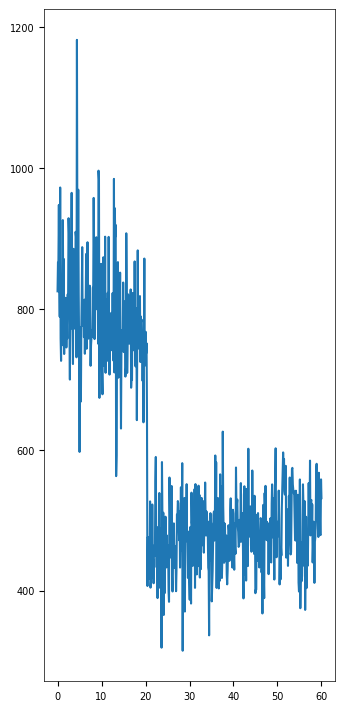

In [32]:
mol = 6
plt.plot(np.linspace(0, 0.1*len(trace_matrix[mol, :]), len(trace_matrix[mol, :])), trace_matrix[mol, :])
#plt.xlim([0, 100])

In [ ]:
# good traces
# 5
# 54
# 119

In [ ]:
vmin=1
vmax=99.9

In [ ]:
locations_forplot = locations[:, [5, 18, 119]]
trace_matrix_forplot = trace_matrix[ [5, 18, 119], :]
trace_matrix_forplot = trace_matrix_forplot.T - np.min(trace_matrix_forplot, axis=1)
trace_matrix_forplot = trace_matrix_forplot.T

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=3, nrows=2, widthratio=[1,1,1], heightratio=[1,1], height=6, width=9)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/FRET/'
plotter.make_animated_gif_bleaching(fig, axs, locations_forplot, trace_matrix_forplot, image_data, 
                                    12, np.linspace(0, 599*0.1, 600), os.path.join(folder, 'FRET_examples.gif'), vmin=1)